# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Faiz Farrosian Karim              |5054251027       |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

In [ ]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

'''

data = pd.read_csv('namafile.csv')
data.head()
data.info()
data.describe()

! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan. 

'''
data = pd.read_csv('WineQT.csv')

data = data.drop(columns=['Id'])

print("Shape:", data.shape)
data.head()
data.info()
data.describe().T
data.isna().sum().to_frame(name='missing_values')
print("Jumlah duplikat:", data.duplicated().sum())


Shape: (1143, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB
Jumlah duplikat: 125


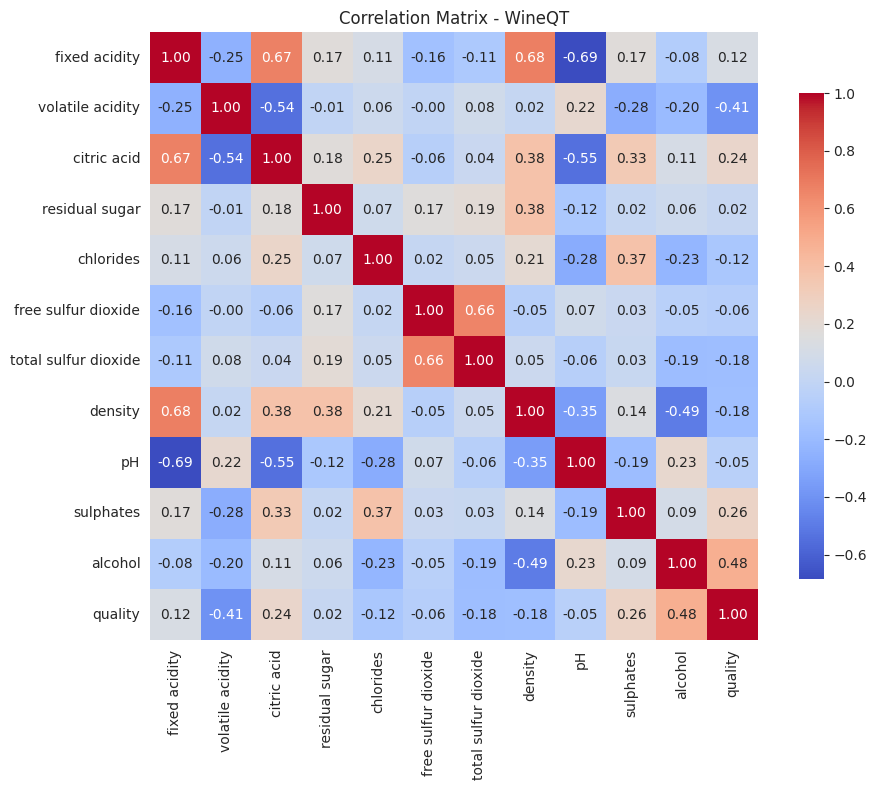

,corr_with_quality
alcohol,0.484866
volatile acidity,-0.407394
sulphates,0.257710
citric acid,0.240821
total sulfur dioxide,-0.183339
density,-0.175208
chlorides,-0.124085
fixed acidity,0.121970
free sulfur dioxide,-0.063260
pH,-0.052453


In [ ]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(10, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"shrink": .8})
plt.title("Correlation Matrix - WineQT")
plt.tight_layout()
plt.show()

corr['quality'].drop('quality').sort_values(key=abs, ascending=False).to_frame('corr_with_quality')


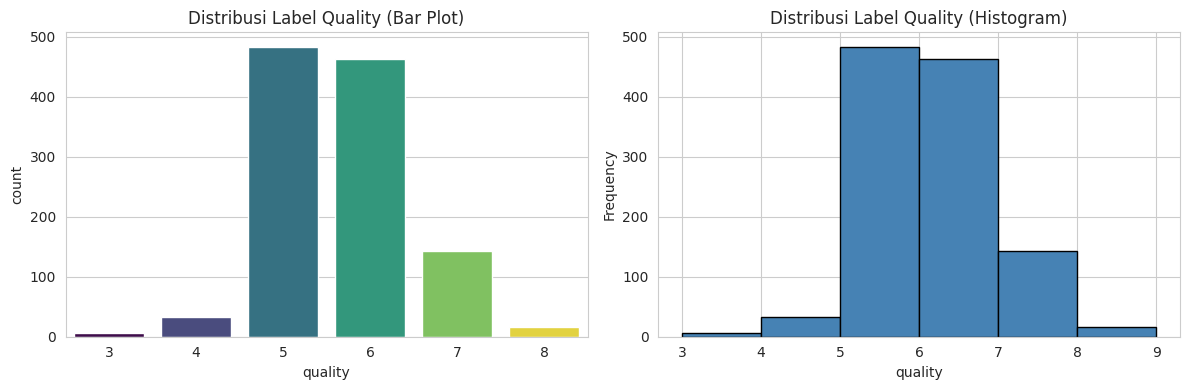

,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


In [ ]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='quality', hue='quality', data=data, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Distribusi Label Quality (Bar Plot)')

data['quality'].plot(kind='hist', bins=range(3, 10), ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Distribusi Label Quality (Histogram)')
axes[1].set_xlabel('quality')

plt.tight_layout()
plt.show()

data['quality'].value_counts().sort_index().to_frame('count')

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

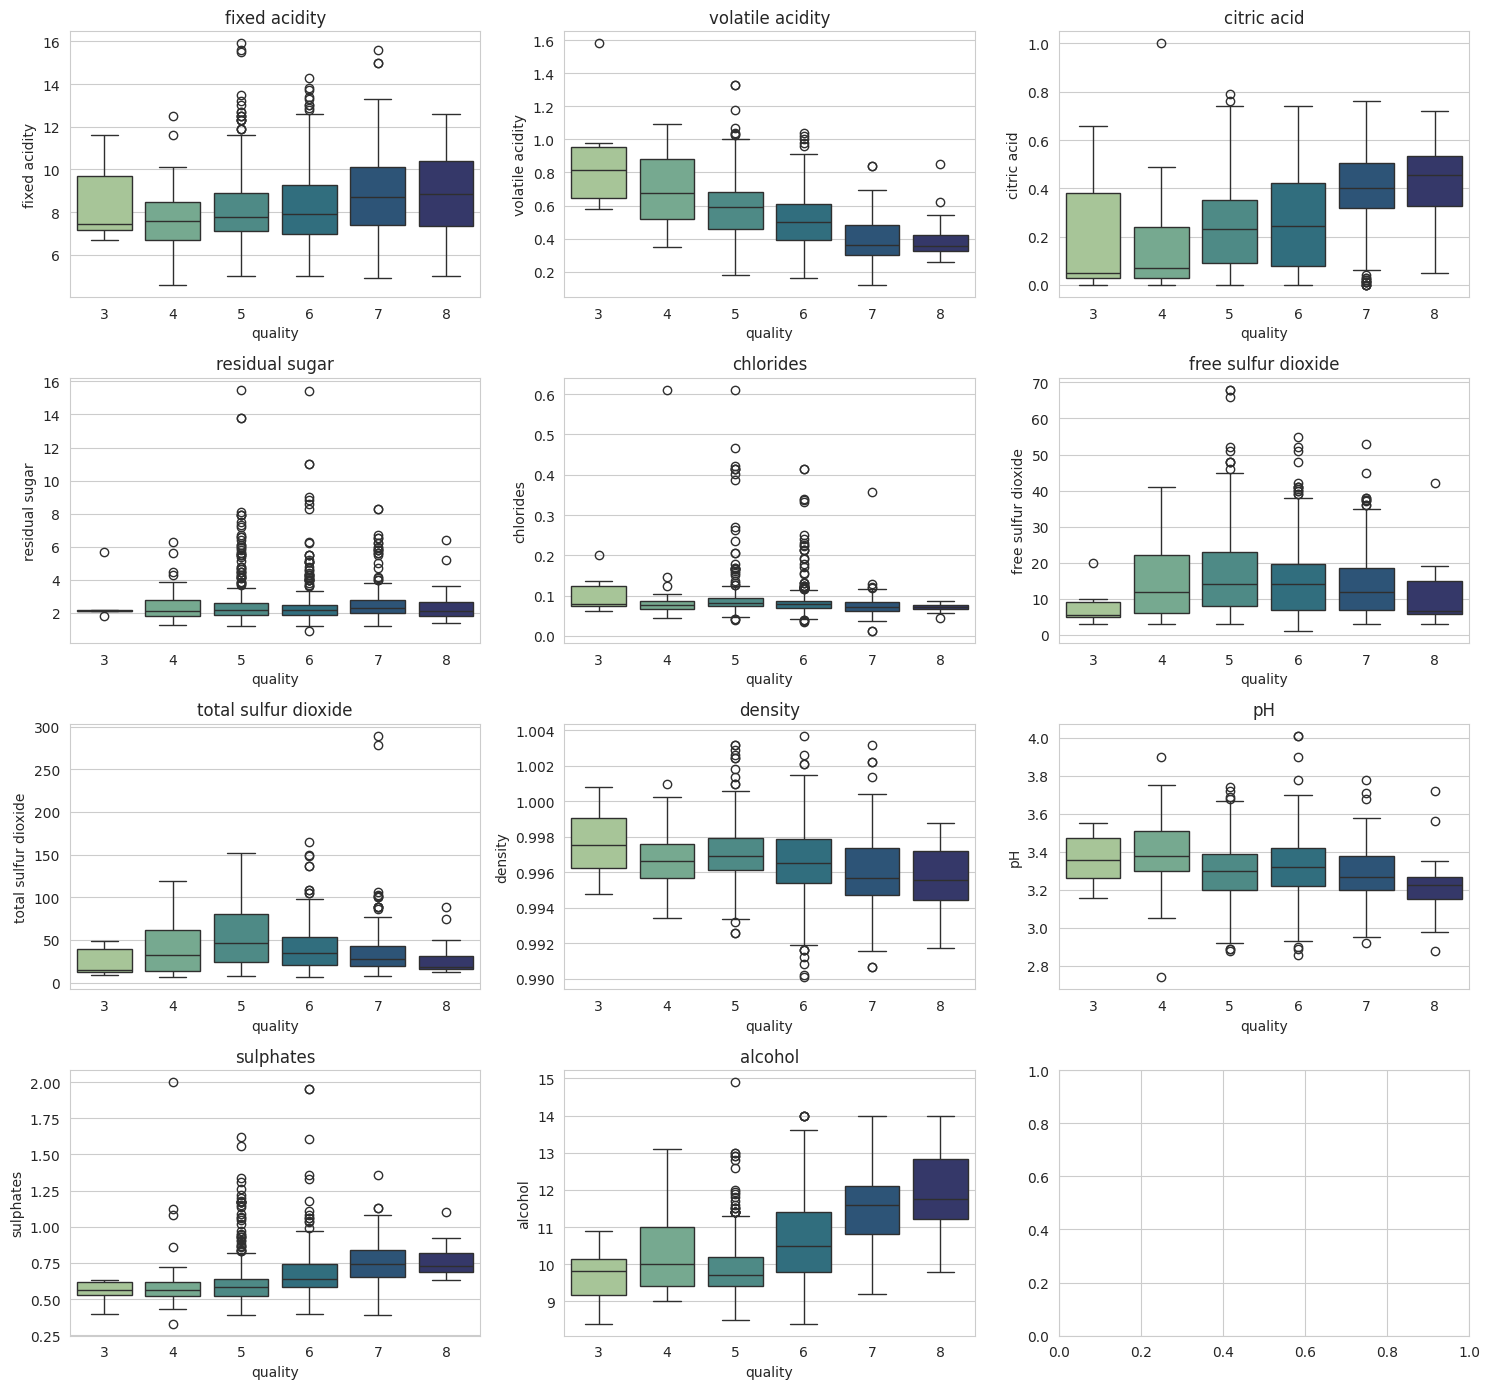

,skewness
chlorides,6.026360
residual sugar,4.361096
sulphates,2.497266
total sulfur dioxide,1.665766
free sulfur dioxide,1.231261
fixed acidity,1.044930
alcohol,0.863313
volatile acidity,0.681547
citric acid,0.371561
pH,0.221138


In [ ]:
# Boxplot tiap fitur numerik terhadap quality, untuk lihat sebaran & potensi outlier per kelas
features = [c for c in data.columns if c != 'quality']

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x='quality', y=col, hue='quality', data=data, ax=axes[i], palette='crest', legend=False)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Skewness tiap fitur numerik
data[features].skew().sort_values(key=abs, ascending=False).to_frame('skewness')

# 2. Preprocessing




In [ ]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
if data.isna().sum().sum() > 0:
    data = data.dropna()  # atau data.fillna(...) tergantung kasus
    print("Baris dengan NaN telah dihapus.")
else:
    print("Tidak ada missing value.")

# Duplicate handling
before = data.shape[0]
data = data.drop_duplicates()
after = data.shape[0]
print(f"Baris sebelum drop duplikat: {before}, sesudah: {after} (dihapus: {before - after})")

Tidak ada missing value.
Baris sebelum drop duplikat: 1143, sesudah: 1018 (dihapus: 125)


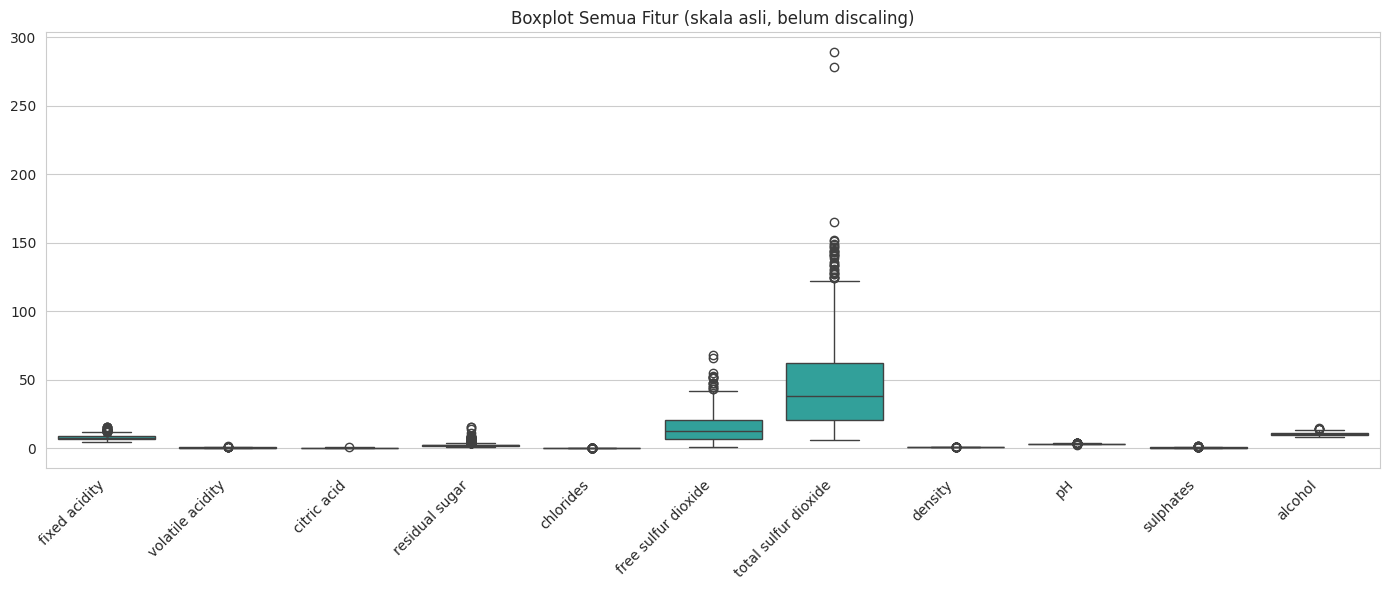

Baris yang mengandung outlier di minimal 1 fitur: 262 dari 1018 (25.7%)
Shape data_with_outliers: (1018, 12)
Shape data_no_outliers  : (756, 12)


In [ ]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
plt.figure(figsize=(14, 6))
sns.boxplot(data=data[features], color='lightseagreen')
plt.xticks(rotation=45, ha='right')
plt.title("Boxplot Semua Fitur (skala asli, belum discaling)")
plt.tight_layout()
plt.show()

# Deteksi outlier per fitur dengan metode IQR
def count_outliers_iqr(df, cols):
    result = {}
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        result[col] = ((df[col] < lower) | (df[col] > upper)).sum()
    return pd.Series(result).sort_values(ascending=False)

outlier_counts = count_outliers_iqr(data, features)
outlier_counts.to_frame('n_outliers_iqr')

# Baris yang outlier di SETIDAKNYA satu fitur (union), dan yang outlier di SEMUA fitur sekaligus
def outlier_mask_iqr(df, cols):
    mask = pd.Series(False, index=df.index)
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        mask = mask | (df[col] < lower) | (df[col] > upper)
    return mask

outlier_row_mask = outlier_mask_iqr(data, features)
print(f"Baris yang mengandung outlier di minimal 1 fitur: {outlier_row_mask.sum()} dari {len(data)} "
      f"({outlier_row_mask.mean()*100:.1f}%)")

# Dua versi dataset untuk eksperimen nanti: dengan outlier & tanpa outlier
data_with_outliers = data.copy()
data_no_outliers = data[~outlier_row_mask].copy()
print("Shape data_with_outliers:", data_with_outliers.shape)
print("Shape data_no_outliers  :", data_no_outliers.shape)

In [ ]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
def split_and_scale(df, test_size=0.2, random_state=RANDOM_STATE, scale=True):
    X = df.drop(columns=['quality'])
    y = df['quality']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    if scale:
        scaler = StandardScaler()
        X_train_out = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
        X_test_out = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
    else:
        X_train_out, X_test_out = X_train, X_test

    return X_train_out, X_test_out, y_train, y_test

print("Fungsi split_and_scale siap dipakai di Bagian 3.")

Fungsi split_and_scale siap dipakai di Bagian 3.


# 3. Eksperimen Model KNN


Train shape: (814, 11) | Test shape: (204, 11)

Distribusi label - train:
quality
3    0.006143
4    0.031941
5    0.425061
6    0.401720
7    0.120393
8    0.014742
Name: proportion, dtype: float64

Distribusi label - test:
quality
3    0.004902
4    0.034314
5    0.426471
6    0.401961
7    0.117647
8    0.014706
Name: proportion, dtype: float64


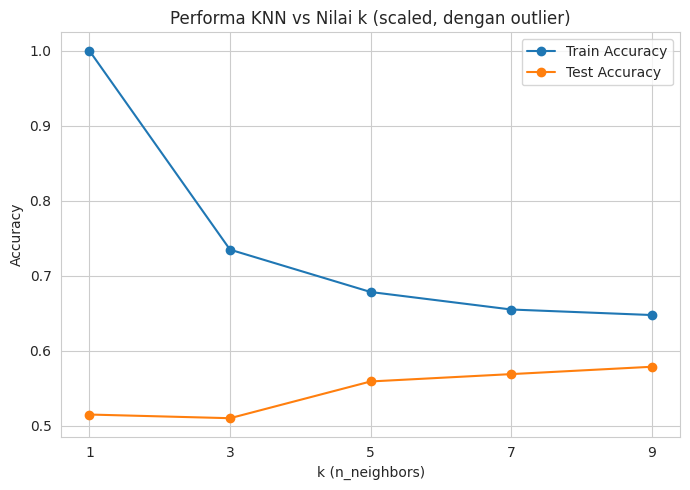

k dengan test accuracy terbaik: k=9


,k,test_accuracy_with_outliers,test_accuracy_no_outliers
0,1,0.514706,0.486842
1,3,0.509804,0.578947
2,5,0.558824,0.559211
3,7,0.568627,0.572368
4,9,0.578431,0.539474


In [ ]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
X = data_with_outliers.drop(columns=['quality'])
y = data_with_outliers['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nDistribusi label - train:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nDistribusi label - test:")
print(y_test.value_counts(normalize=True).sort_index())

#scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']]

#eksperimen nilai k
k_values = [1, 3, 5, 7, 9]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

    results.append({'k': k, 'train_accuracy': train_acc, 'test_accuracy': test_acc})

results_df = pd.DataFrame(results)
results_df

plt.figure(figsize=(7, 5))
plt.plot(results_df['k'], results_df['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(results_df['k'], results_df['test_accuracy'], marker='o', label='Test Accuracy')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('Performa KNN vs Nilai k (scaled, dengan outlier)')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

best_k = int(results_df.loc[results_df['test_accuracy'].idxmax(), 'k'])
print(f"k dengan test accuracy terbaik: k={best_k}")

#eksperimen pengaruh scaling
results_no_scale = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, knn.predict(X_test))
    results_no_scale.append({'k': k, 'test_accuracy_no_scaling': test_acc})

scale_comparison = results_df[['k', 'test_accuracy']].rename(columns={'test_accuracy': 'test_accuracy_scaled'})
scale_comparison = scale_comparison.merge(pd.DataFrame(results_no_scale), on='k')
scale_comparison

#eksperimen pengaruh outlier
X_train_no, X_test_no, y_train_no, y_test_no = split_and_scale(data_no_outliers, scale=True)

results_outlier = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_no, y_train_no)
    test_acc = accuracy_score(y_test_no, knn.predict(X_test_no))
    results_outlier.append({'k': k, 'test_accuracy_no_outliers': test_acc})

outlier_comparison = results_df[['k', 'test_accuracy']].rename(columns={'test_accuracy': 'test_accuracy_with_outliers'})
outlier_comparison = outlier_comparison.merge(pd.DataFrame(results_outlier), on='k')
outlier_comparison

# 4. Evaluasi Model


Accuracy          : 0.5784
Precision (macro)  : 0.2785   | Precision (weighted): 0.5544
Recall (macro)     : 0.2725   | Recall (weighted)   : 0.5784
F1-score (macro)   : 0.2726   | F1-score (weighted) : 0.5627
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.67      0.66      0.66        87
           6       0.53      0.65      0.58        82
           7       0.47      0.33      0.39        24
           8       0.00      0.00      0.00         3

    accuracy                           0.58       204
   macro avg       0.28      0.27      0.27       204
weighted avg       0.55      0.58      0.56       204



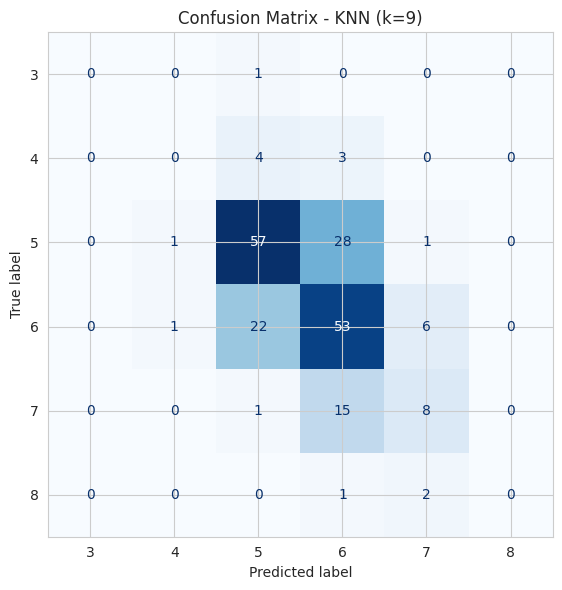

In [ ]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy          : {acc:.4f}")
print(f"Precision (macro)  : {prec_macro:.4f}   | Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (macro)     : {rec_macro:.4f}   | Recall (weighted)   : {rec_weighted:.4f}")
print(f"F1-score (macro)   : {f1_macro:.4f}   | F1-score (weighted) : {f1_weighted:.4f}")

print(classification_report(y_test, y_pred, zero_division=0))

labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix - KNN (k={best_k})')
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

### a. Pengaruh nilai k

| k | Train Accuracy | Test Accuracy |
|---|---|---|
| 1 | 1.000 | 0.515 |
| 3 | 0.735 | 0.510 |
| 5 | 0.678 | 0.559 |
| 7 | 0.655 | 0.569 |
| 9 | 0.647 | **0.578** |

Saat k=1, train accuracy sampai 100% tapi test accuracy cuma 51%. Ini overfitting: model terlalu "menghafal" data latih, jadi begitu ketemu data baru (test set) hasilnya jelek. Semakin besar nilai k yang dicoba (3, 5, 7, 9), gap antara train accuracy dan test accuracy makin kecil, dan test accuracy-nya justru naik. Dari 5 nilai k yang dicoba, **k=9 hasilnya paling bagus** (test accuracy 57.8%).

### b. Pengaruh Scaling

| k | Test Acc (discaling) | Test Acc (tanpa scaling) |
|---|---|---|
| 1 | 0.515 | 0.441 |
| 3 | 0.510 | 0.397 |
| 5 | 0.559 | 0.471 |
| 7 | 0.569 | 0.500 |
| 9 | **0.578** | 0.475 |

Data yang discaling selalu menghasilkan accuracy lebih tinggi dibanding yang tidak discaling, di semua nilai k. Ini masuk akal karena KNN bekerja dengan menghitung jarak antar data, jadi kalau skala fiturnya beda-beda jauh (misalnya `total sulfur dioxide` yang nilainya bisa ratusan, dibanding `chlorides` yang nilainya kecil), fitur dengan angka besar akan lebih "mendominasi" perhitungan jarak walaupun belum tentu lebih penting. Jadi scaling memang perlu dilakukan.

### c. Pengaruh Menghapus Outlier

| k | Test Acc (dengan outlier) | Test Acc (tanpa outlier) |
|---|---|---|
| 1 | **0.515** | 0.487 |
| 3 | 0.510 | **0.579** |
| 5 | 0.559 | 0.559 |
| 7 | 0.569 | **0.572** |
| 9 | **0.578** | 0.539 |

Hasilnya naik-turun, tidak selalu lebih baik kalau outlier dihapus. Kadang naik (k=3, k=7), kadang malah turun (k=1, k=9). Kemungkinan karena setelah outlier dihapus, jumlah datanya jadi lebih sedikit, jadi tidak selalu menguntungkan. Jadi untuk dataset ini, menghapus outlier belum tentu membuat model lebih baik.

### d. Analisis Hasil Evaluasi Model Final (k=9)

Accuracy keseluruhan model adalah **57.8%**. Tapi kalau dilihat dari `classification_report`, ada perbedaan besar antar kelas:
- Kelas **quality 5 dan 6** (yang datanya paling banyak) hasilnya lumayan bagus, F1-score sekitar 0.58-0.66
- Kelas **quality 3, 4, dan 8** (yang datanya sangat sedikit, cuma 1-7 sampel di data test) hasilnya **0**. Model sama sekali tidak berhasil menebak kelas-kelas ini dengan benar

Ini terjadi karena jumlah data untuk kelas 3, 4, dan 8 memang sangat sedikit dibanding kelas 5 dan 6, jadi model lebih "condong" menebak kelas yang datanya banyak. Ini juga alasan kenapa `macro avg` (≈0.27) jauh lebih rendah dari `weighted avg` (≈0.56). Macro avg menghitung rata-rata semua kelas sama rata, jadi kelihatan jelas kalau model gagal di kelas yang datanya sedikit.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan

1. Model terbaik dari eksperimen ini adalah **KNN dengan k=9**, menggunakan data yang **discaling**, dan **tidak menghapus outlier**. Test accuracy-nya **57.8%**.
2. **Scaling penting** untuk KNN, terbukti selalu menaikkan accuracy di semua nilai k yang dicoba.
3. **Menghapus outlier belum tentu membantu**, di beberapa nilai k malah menurunkan accuracy.
4. Nilai k yang terlalu kecil (k=1) menyebabkan **overfitting**.
5. Model ini masih **lemah untuk memprediksi kelas yang datanya sedikit** (quality 3, 4, 8), karena kebanyakan data yang ada hanya untuk quality 5, 6, dan 7.

### Saran

- Coba nilai k yang lebih banyak lagi (misalnya 11, 15, 21) untuk lihat apakah accuracy-nya masih bisa naik.
- Cari cara supaya jumlah data tiap kelas lebih seimbang, misalnya dengan menggabungkan kategori quality yang mirip (misal jadi "rendah", "sedang", "tinggi") supaya modelnya tidak terlalu berat sebelah ke kelas mayoritas.
- Coba metode deteksi outlier lain selain IQR, siapa tahu hasilnya beda.
- Kalau ada waktu, bisa coba bandingkan dengan model klasifikasi lain (misalnya Decision Tree) untuk lihat mana yang lebih cocok untuk dataset ini.